Step 1: Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from math import sqrt
from surprise import Dataset, Reader, SVD, NMF, KNNBasic
from surprise.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# For display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Step 2: Load MovieLens Dataset

In [ ]:
# Load ratings and movies metadata
ratings_df = pd.read_csv("movielens/ratings.csv")     # userId, movieId, rating, timestamp
movies_df = pd.read_csv("movielens/movies.csv")       # movieId, title, genres

# Merge metadata for content-based work in Week 3
merged_df = pd.merge(ratings_df, movies_df, on="movieId")

# Check for nulls
print("Missing values:\n", merged_df.isnull().sum())

# Drop unnecessary columns for now
ratings_df = merged_df[['userId', 'movieId', 'rating']]

Missing values:
 userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


Step 3: EDA

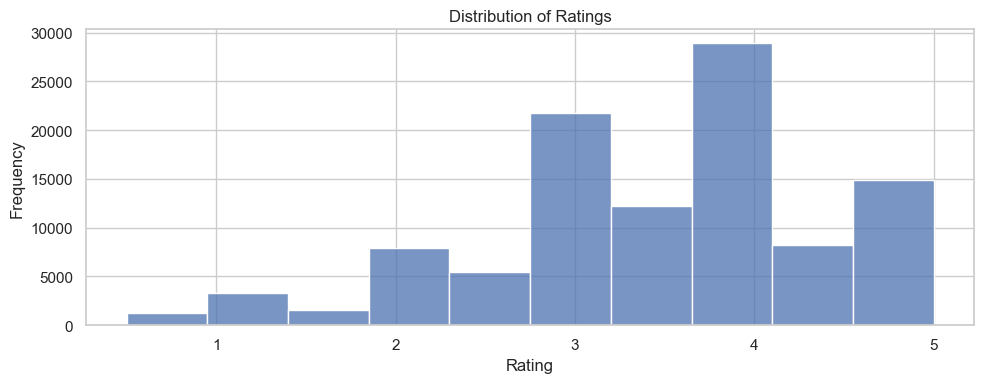

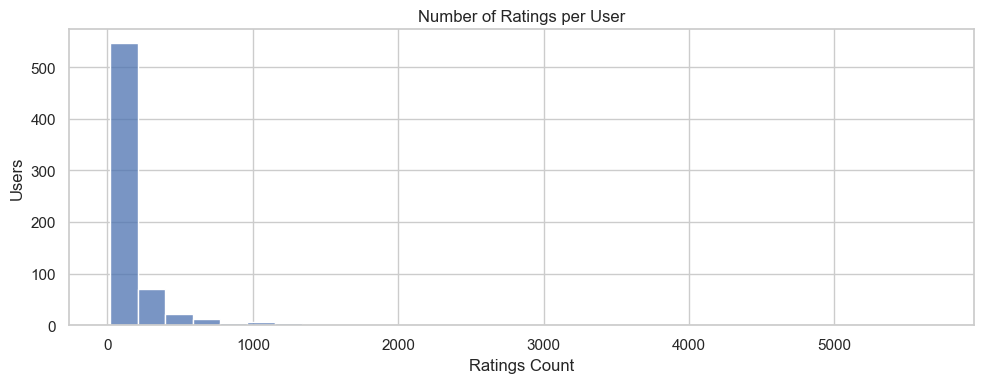

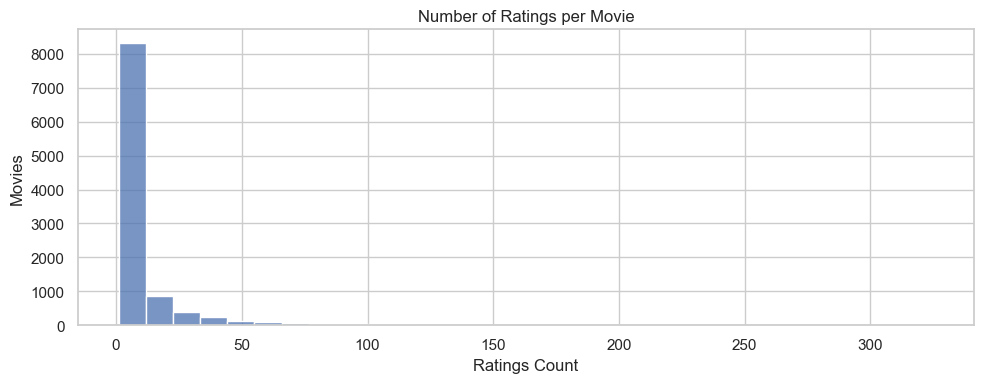

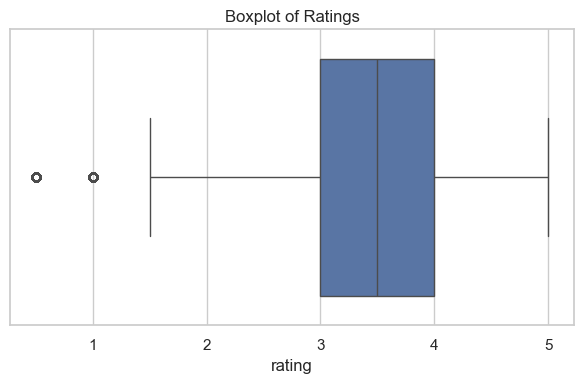

Outlier Ratings (not between 1 and 5):
        userId  movieId  rating
9            1      204     0.5
11           1      256     0.5
14           1      277     0.5
31           1      719     0.5
106          1    45950     0.5
...        ...      ...     ...
105042     668   103339     0.5
105052     668   103596     0.5
105138     668   108729     0.5
105216     668   113345     0.5
105284     668   121308     0.5

[1198 rows x 3 columns]


In [ ]:
# Rating distribution
plt.figure(figsize=(10, 4))
sns.histplot(ratings_df['rating'], bins=10, kde=False)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Ratings per user
ratings_per_user = ratings_df.groupby('userId')['rating'].count()
plt.figure(figsize=(10, 4))
sns.histplot(ratings_per_user, bins=30, kde=False)
plt.title("Number of Ratings per User")
plt.xlabel("Ratings Count")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

# Ratings per movie
ratings_per_movie = ratings_df.groupby('movieId')['rating'].count()
plt.figure(figsize=(10, 4))
sns.histplot(ratings_per_movie, bins=30, kde=False)
plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings Count")
plt.ylabel("Movies")
plt.tight_layout()
plt.show()

# Boxplot for outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x='rating', data=ratings_df)
plt.title("Boxplot of Ratings")
plt.tight_layout()
plt.show()

# Check for rating outliers
print("Outlier Ratings (not between 1 and 5):")
print(ratings_df[(ratings_df['rating'] < 1) | (ratings_df['rating'] > 5)])

Step 4: Prepare Surprise Dataset

In [ ]:
reader = Reader(rating_scale=(0.5, 5.0))  # MovieLens 100K uses 0.5–5.0
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

Step 5: Collaborative Filtering Models

In [ ]:
# User-Based Collaborative Filtering
user_knn = KNNBasic(sim_options={'user_based': True})
user_knn.fit(trainset)
user_preds = user_knn.test(testset)

# Item-Based Collaborative Filtering
item_knn = KNNBasic(sim_options={'user_based': False})
item_knn.fit(trainset)
item_preds = item_knn.test(testset)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


In [7]:
# ------------ Step 6: Matrix Factorization Models ------------

# SVD
svd_model = SVD()
svd_model.fit(trainset)
svd_preds = svd_model.test(testset)

# NMF
nmf_model = NMF()
nmf_model.fit(trainset)
nmf_preds = nmf_model.test(testset)

In [8]:
# ------------ Step 7: Evaluation Functions ------------

def calculate_rmse(preds):
    return sqrt(mean_squared_error([pred.r_ui for pred in preds], [pred.est for pred in preds]))

def calculate_mae(preds):
    return mean_absolute_error([pred.r_ui for pred in preds], [pred.est for pred in preds])

def precision_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)
    for pred in predictions:
        user_est_true[pred.uid].append((pred.est, pred.r_ui))
    precisions = []
    for user, ratings in user_est_true.items():
        ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = ratings[:k]
        relevant = sum((true_r >= threshold) for (_, true_r) in top_k)
        precisions.append(relevant / k)
    return np.mean(precisions)


In [9]:
# ------------ Step 8: Evaluation Results ------------

def print_metrics(name, predictions):
    rmse = calculate_rmse(predictions)
    mae = calculate_mae(predictions)
    precision = precision_at_k(predictions, k=5)
    print(f"\n===== {name} Evaluation =====")
    print(f"RMSE       : {rmse:.4f}")
    print(f"MAE        : {mae:.4f}")
    print(f"Precision@5: {precision:.4f}")

# Evaluate all models
print_metrics("User-Based Collaborative Filtering", user_preds)
print_metrics("Item-Based Collaborative Filtering", item_preds)
print_metrics("SVD Matrix Factorization", svd_preds)
print_metrics("NMF Matrix Factorization", nmf_preds)


===== User-Based Collaborative Filtering Evaluation =====
RMSE       : 0.9555
MAE        : 0.7369
Precision@5: 0.7257

===== Item-Based Collaborative Filtering Evaluation =====
RMSE       : 0.9097
MAE        : 0.7038
Precision@5: 0.6901

===== SVD Matrix Factorization Evaluation =====
RMSE       : 0.8654
MAE        : 0.6698
Precision@5: 0.7359

===== NMF Matrix Factorization Evaluation =====
RMSE       : 0.9262
MAE        : 0.7136
Precision@5: 0.7072
